<a href="https://colab.research.google.com/github/DemydovaAnna/python_for_da_tasks/blob/main/Copy_of_HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Dataloveacademy/Модуль 11. Візуалізація даних для аналізу з бібліотеками matplotlib, seaborn, plotly/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

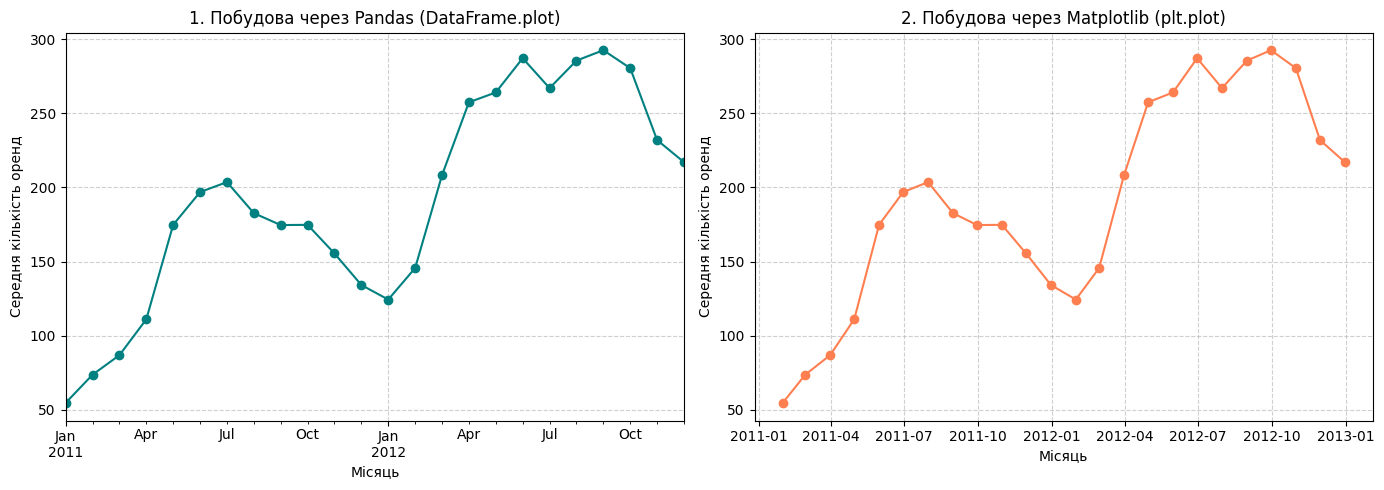

In [11]:
monthly_mean = df.resample('ME')['count'].mean()
plt.figure(figsize=(14, 5))

#Спосіб 1: Побудова через Pandas
plt.subplot(1, 2, 1)
monthly_mean.plot(marker='o', color='teal')
plt.title("1. Побудова через Pandas (DataFrame.plot)")
plt.xlabel("Місяць")
plt.ylabel("Середня кількість оренд")
plt.grid(True, linestyle='--', alpha=0.6)

#Спосіб 2: Побудова через Matplotlib безпосередньо
plt.subplot(1, 2, 2)
plt.plot(monthly_mean.index, monthly_mean.values, marker='o', color='coral')
plt.title("2. Побудова через Matplotlib (plt.plot)")
plt.xlabel("Місяць")
plt.ylabel("Середня кількість оренд")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Обидва графіки показують абсолютно однаковий тренд та дані.

Відмінності в коді та автоналаштуваннях:

Pandas: Автоматично бере часовий індекс для осі X, підставляє назву серії даних і форматує підписи дат на осі X. Написання коду вимагає менше параметрів.

Matplotlib: Вимагає явного передавання масивів для осі X (⁠monthly_mean.index⁠) та осі Y (⁠monthly_mean.values⁠), проте надає більший контроль над кожним елементом графіку.

Для швидкої аналітики та дослідження даних зручніший метод Pandas, але для гнучкого налаштування складних візуалізацій краще підходить Matplotlib.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [12]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

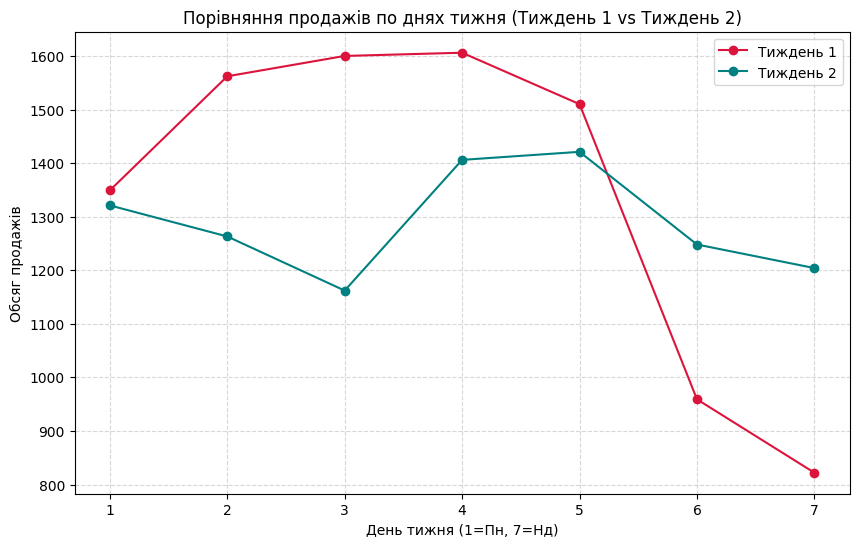

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(days, sales_week1, marker='o', color='crimson', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', color='teal', label='Тиждень 2')

plt.title("Порівняння продажів по днях тижня (Тиждень 1 vs Тиждень 2)")
plt.xlabel("День тижня (1=Пн, 7=Нд)")
plt.ylabel("Обсяг продажів")
plt.xticks(days)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [16]:
#Рахуємо стандартне відхилення для кожного тижня за допомогою numpy
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)
print(f"Стандартне відхилення для Тижня 1: {std_week1:.2f}")
print(f"Стандартне відхилення для Тижня 2: {std_week2:.2f}")

Стандартне відхилення для Тижня 1: 300.00
Стандартне відхилення для Тижня 2: 90.91


1. Судячи з графіку, в який тиждень проодажі були стабільніше?

Продажі були стабільнішими у Тиждень 2.

2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

На графіку видно, що у Тиждень 1 відбувся різкий провал у вихідні дні. У Тиждень 2 лінія більш рівна, без гострих стрибків.
 Математичне підтвердження: Розрахунок стандартного відхилення (⁠np.std⁠) показує, що для Тижня 1 розкид даних більший - 300, ніж для Тижня 2 - 90,91. Менший розкид свідчить про вищу стабільність.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

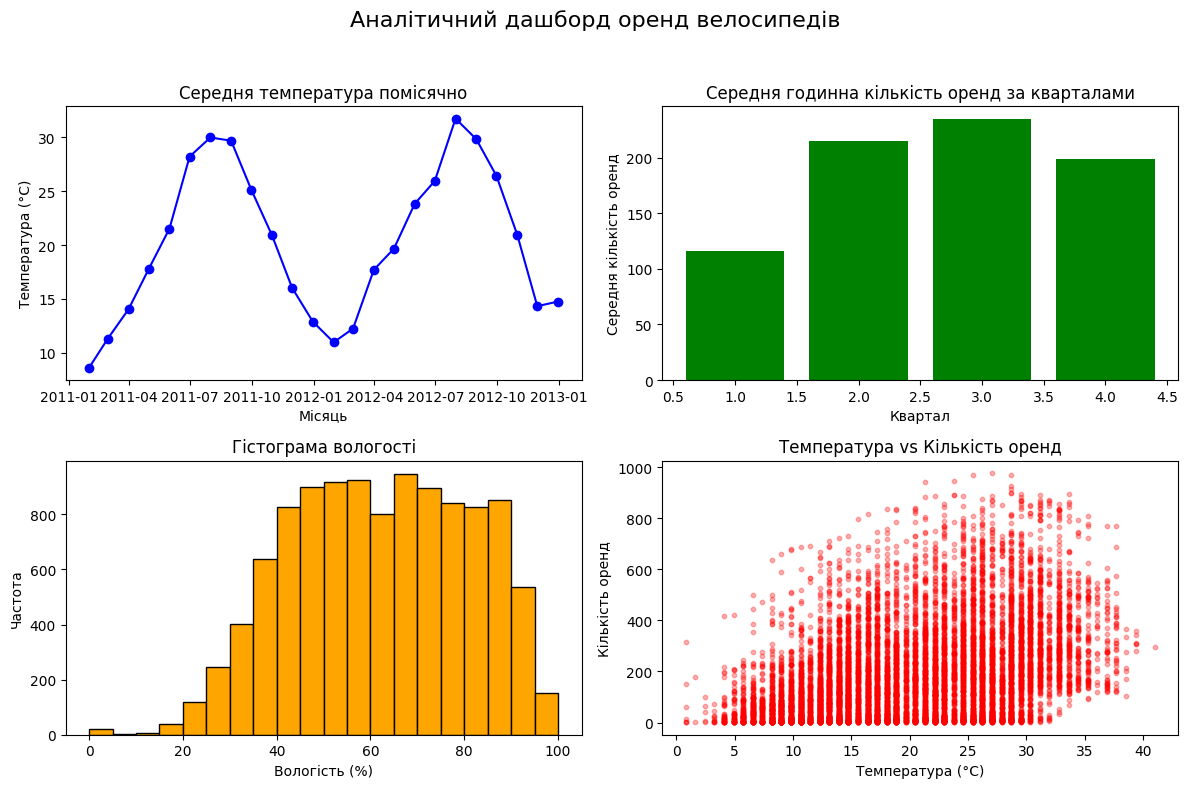

In [17]:
monthly_temp = df.resample('ME')['temp'].mean()
quarterly_hourly_rent = df.groupby('season')['count'].mean()

plt.figure(figsize=(12, 8))

#Графік 1: Лінійний графік середньої температури помісячно
plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp.values, color='blue', marker='o')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура (°C)')

#Графік 2: Стовпчикова діаграма оренд за кварталами
plt.subplot(2, 2, 2)
plt.bar(quarterly_hourly_rent.index, quarterly_hourly_rent.values, color='green')
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')

#Графік 3: Гістограма вологості за всіма вимірами
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='orange', edgecolor='black')
plt.title('Гістограма вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')

#Графік 4: Scatter plot температури vs кількості оренд
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], color='red', alpha=0.3, s=10)
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

plt.suptitle('Аналітичний дашборд оренд велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

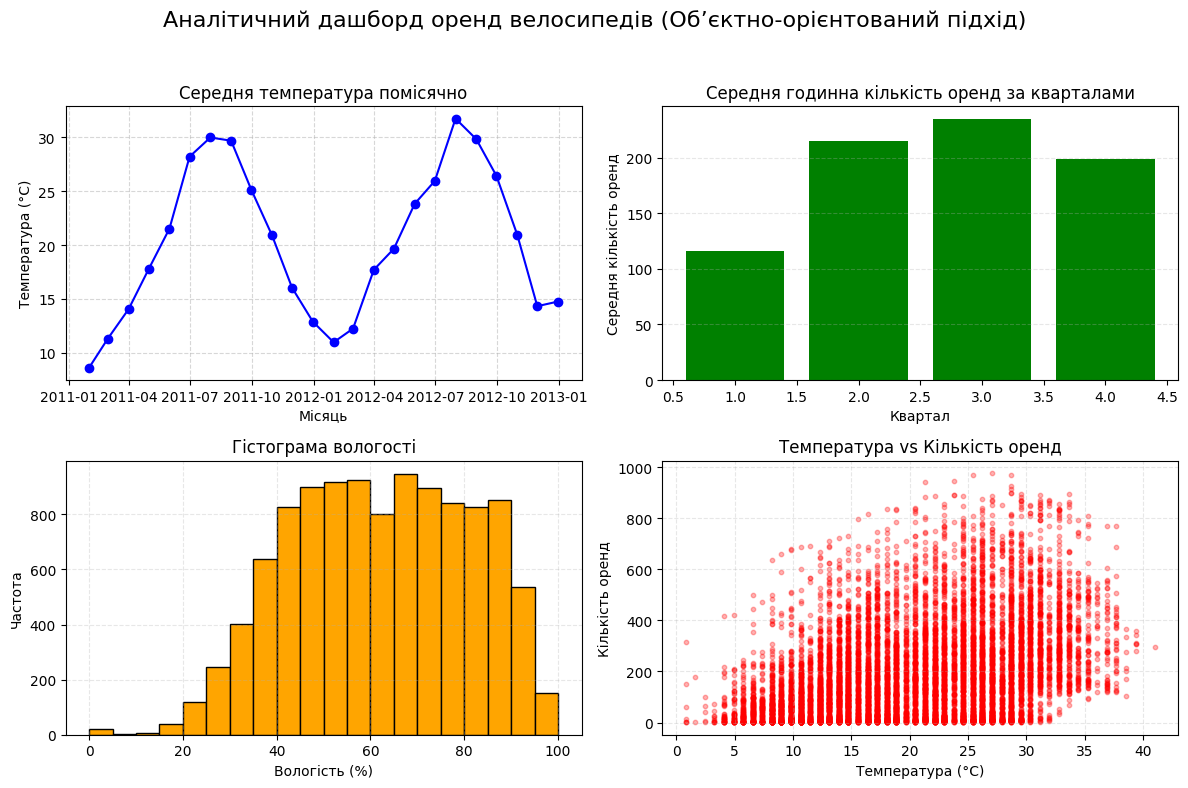

In [18]:
monthly_temp = df.resample('ME')['temp'].mean()
quarterly_hourly_rent = df.groupby('season')['count'].mean()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

#Графік 1: Лінійний графік середньої температури помісячно
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, color='blue', marker='o')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True, linestyle='--', alpha=0.5)

#Графік 2: Стовпчикова діаграма оренд за кварталами
ax[0, 1].bar(quarterly_hourly_rent.index, quarterly_hourly_rent.values, color='green')
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')
ax[0, 1].grid(True, linestyle='--', alpha=0.3, axis='y')

#Графік 3: Гістограма вологості за всіма вимірами
ax[1, 0].hist(df['humidity'], bins=20, color='orange', edgecolor='black')
ax[1, 0].set_title('Гістограма вологості')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота')
ax[1, 0].grid(True, linestyle='--', alpha=0.3)

#Графік 4: Scatter plot температури vs кількості оренд
ax[1, 1].scatter(df['temp'], df['count'], color='red', alpha=0.3, s=10)
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')
ax[1, 1].grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Аналітичний дашборд оренд велосипедів (Обʼєктно-орієнтований підхід)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?**

plt.subplot()⁠ (імперативний): Створює підграфіки по черзі по одному. Кожен виклик активує потрібний графік, а налаштування робляться через команду ⁠plt.⁠ (наприклад, ⁠plt.title()⁠).

 ⁠plt.subplots()⁠ (декларативний і модульний спосіб): Одразу створює всю сітку графіків і повертає масив осей ⁠ax⁠. До будь-якого графіка можна зручно звернутися за індексом (наприклад, ⁠ax[0, 1]⁠), а налаштування робляться через методи ⁠.set_*⁠ (наприклад, ⁠.set_title()⁠). Це більш гнучкий та професійний підхід.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [19]:
import matplotlib.dates as mdates

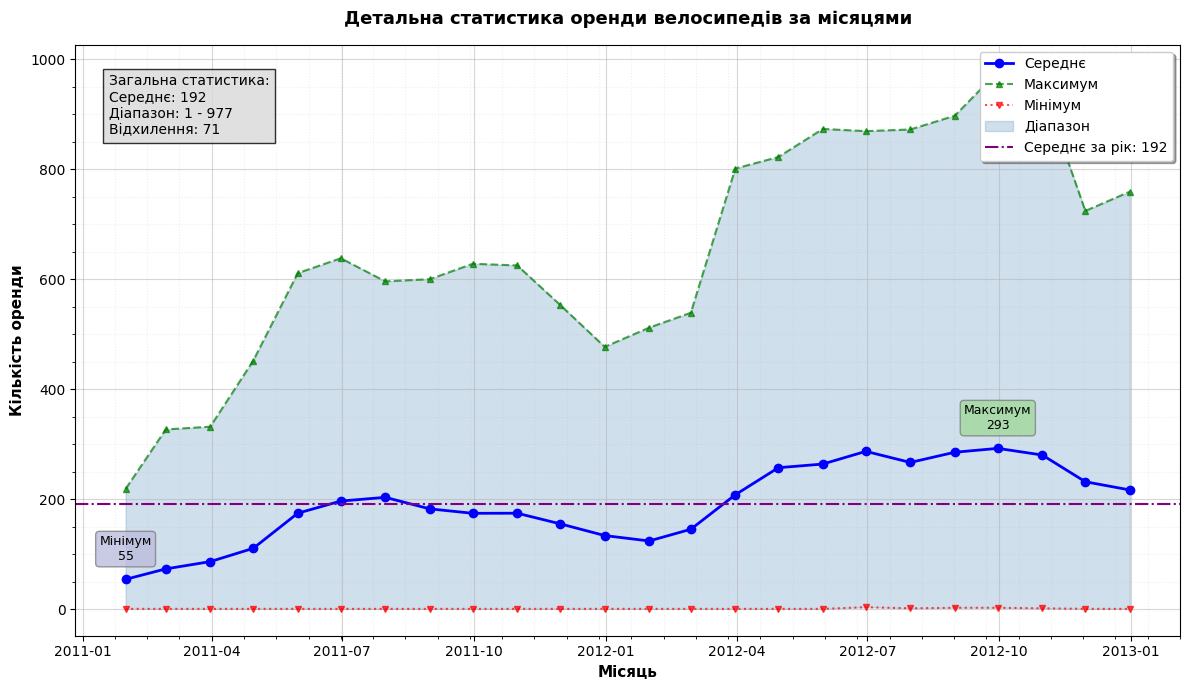

In [25]:
monthly_stats = df.resample('ME')['count'].agg(['mean', 'max', 'min'])

overall_mean = df['count'].mean()
overall_min = df['count'].min()
overall_max = df['count'].max()
overall_std = monthly_stats['mean'].std()

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=2,
        label='Середнє', markersize=6)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=1.5,
        label='Максимум', markersize=5, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=1.5,
        label='Мінімум', markersize=5, alpha=0.7)

ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.25, color='#4682B4', label='Діапазон')

ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=1.5,
           label=f'Середнє за рік: {overall_mean:.0f}')

max_idx = monthly_stats['mean'].idxmax()
max_val = monthly_stats['mean'].max()
ax.annotate(f'Максимум\n{max_val:.0f}', xy=(max_idx, max_val), xytext=(max_idx, max_val + 35),
            ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#a1d99b', edgecolor='gray', alpha=0.8))

min_idx = monthly_stats['mean'].idxmin()
min_val = monthly_stats['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}', xy=(min_idx, min_val), xytext=(min_idx, min_val + 35),
            ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#bcbddc', edgecolor='gray', alpha=0.8))

ax.set_title("Детальна статистика оренди велосипедів за місяцями", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Місяць", fontsize=11, fontweight='bold')
ax.set_ylabel("Кількість оренди", fontsize=11, fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

textstr = f"Загальна статистика:\nСереднє: {overall_mean:.0f}\nДіапазон: {overall_min:.0f} - {overall_max:.0f}\nВідхилення: {overall_std:.0f}"
props = dict(boxstyle='square,pad=0.4', facecolor='#d9d9d9', edgecolor='black', alpha=0.8)
ax.text(0.03, 0.95, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)

ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)
plt.tight_layout()
plt.show()